<a href="https://colab.research.google.com/github/khoihole329-sudo/Minhkhoi/blob/main/L%C3%80M%20S%E1%BA%A0CH%20D%E1%BB%AE%20LI%E1%BB%86U%20C%C6%A0%20B%E1%BA%A2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Câu 1: Nạp và Khám phá dữ liệu

In [2]:
df = sns.load_dataset("titanic")
print("5 dòng đầu tiên:")
display(df.head())

print("Thông tin dữ liệu:")
df.info()

5 dòng đầu tiên:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Câu 2: Xử lý giá trị khuyết (1.5 điểm)

In [3]:

print("Số lượng giá trị khuyết:")
print(df.isnull().sum())

Số lượng giá trị khuyết:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
df = df.drop(columns=["deck"])
mean_age = df["age"].mean()
print("Tuổi trung bình:", mean_age)
df["age"] = df["age"].fillna(mean_age)
print("Số giá trị khuyết sau khi xử lý:")
print(df.isnull().sum())

Tuổi trung bình: 29.69911764705882
Số giá trị khuyết sau khi xử lý:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


##Câu 3: Phân tích và Trực quan hóa (2.0 điểm)

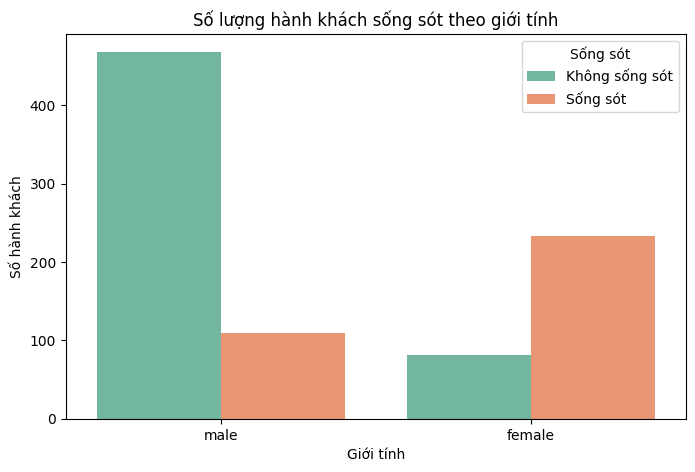

In [5]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="survived",
    palette="Set2"
)

plt.title("Số lượng hành khách sống sót theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số hành khách")
plt.legend(
    title="Sống sót",
    labels=["Không sống sót", "Sống sót"]
)

plt.show()

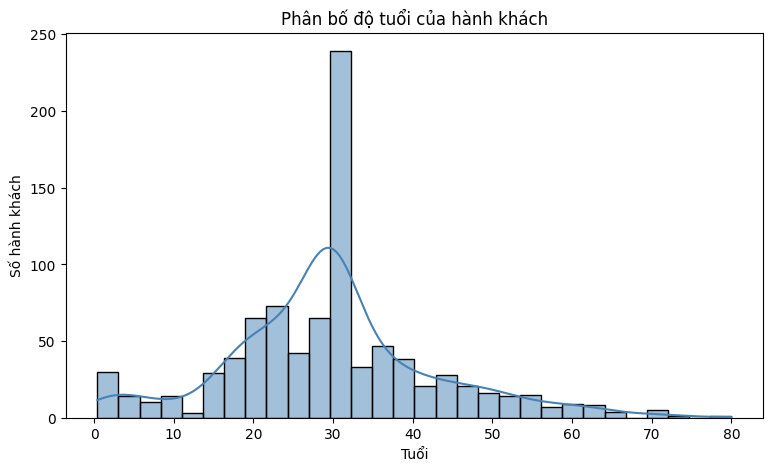

In [6]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Phân bố độ tuổi của hành khách")
plt.xlabel("Tuổi")
plt.ylabel("Số hành khách")

plt.show()

In [7]:

numeric_columns = ["survived", "pclass", "age", "fare"]
correlation_matrix = df[numeric_columns].corr()

print("Ma trận tương quan:")
display(correlation_matrix)

Ma trận tương quan:


,survived,pclass,age,fare
survived,1.000000,-0.338481,-0.069809,0.257307
pclass,-0.338481,1.000000,-0.331339,-0.549500
age,-0.069809,-0.331339,1.000000,0.091566
fare,0.257307,-0.549500,0.091566,1.000000


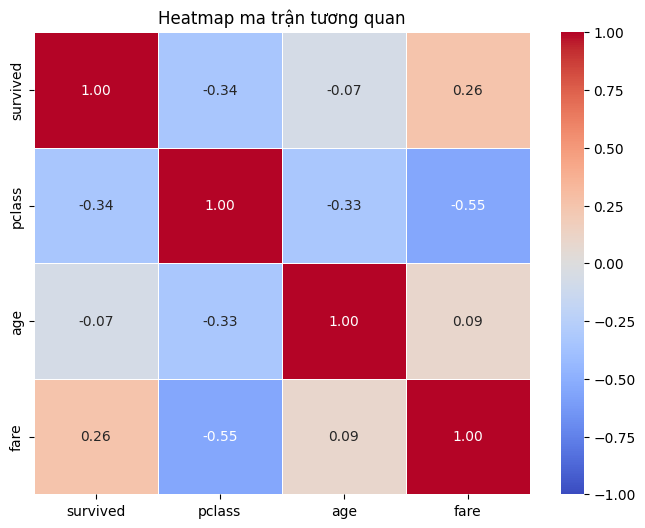

In [8]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Heatmap ma trận tương quan")
plt.show()

## Câu 4: Mã hóa dữ liệu

In [9]:
df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

print("Kết quả mã hóa cột sex:")
display(df[["sex"]].head())

Kết quả mã hóa cột sex:


,sex
0,0
1,1
2,1
3,1
4,0


In [10]:
embarked_mode = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(embarked_mode)
embarked_dummies = pd.get_dummies(
    df["embarked"],
    prefix="embarked",
    dtype=int
)

df = df.drop(columns=["embarked"])
df = pd.concat([df, embarked_dummies], axis=1)

print("Dữ liệu sau khi One-Hot Encoding:")
display(df.head())

Dữ liệu sau khi One-Hot Encoding:


,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,0,0,1
1,1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,1,0,0
2,1,3,1,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,0,0,1
3,1,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,0,0,1
4,0,3,0,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,0,0,1


In [11]:
print("Các cột trong DataFrame:")
print(df.columns.tolist())

Các cột trong DataFrame:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'embarked_C', 'embarked_Q', 'embarked_S']


## Câu 5: Chuẩn bị dữ liệu cho học sâu

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X gồm 3 đặc trưng
X = df[["pclass", "sex", "age"]]

# y là nhãn cần dự đoán
y = df["survived"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

display(X.head())
display(y.head())

Kích thước X: (891, 3)
Kích thước y: (891,)


,pclass,sex,age
0,3,0,22.0
1,1,1,38.0
2,3,1,26.0
3,1,1,35.0
4,3,0,35.0


,survived
0,0
1,1
2,1
3,1
4,0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước y_test:", y_test.shape)

Kích thước X_train: (712, 3)
Kích thước X_test: (179, 3)
Kích thước y_train: (712,)
Kích thước y_test: (179,)


In [14]:
scaler = StandardScaler()

# Chỉ fit trên tập train để tránh rò rỉ dữ liệu
X_train_scaled = scaler.fit_transform(X_train)

# Tập test chỉ được transform
X_test_scaled = scaler.transform(X_test)

print("5 dòng đầu của X_train sau khi chuẩn hóa:")
print(X_train_scaled[:5])

5 dòng đầu của X_train sau khi chuẩn hóa:
[[ 0.82956755 -0.74242727 -0.00674143]
 [-0.37094484 -0.74242727 -0.00674143]
 [-1.57145722 -0.74242727 -0.00674143]
 [ 0.82956755  1.34693328 -0.90625969]
 [-0.37094484  1.34693328  0.09328043]]


## Câu 6: Xây dựng mạng nơ-ron ANN

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Đặt seed để kết quả dễ tái lập
np.random.seed(42)
tf.random.set_seed(42)

# Xây dựng mô hình
model = Sequential([
    Input(shape=(3,)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile mô hình
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Hiển thị cấu trúc mô hình
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.5571 - loss: 0.6882 - val_accuracy: 0.5874 - val_loss: 0.6841
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6837 - loss: 0.6578 - val_accuracy: 0.6923 - val_loss: 0.6553
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7663 - loss: 0.6297 - val_accuracy: 0.7273 - val_loss: 0.6286
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7715 - loss: 0.6039 - val_accuracy: 0.7552 - val_loss: 0.6044
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7768 - loss: 0.5804 - val_accuracy: 0.7692 - val_loss: 0.5828
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7786 - loss: 0.5591 - val_accuracy: 0.7622 - val_loss: 0.5636
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7803 - loss: 0.5399 - val_accuracy: 0.7552 - val_loss: 0.5465
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7803 - loss: 0.5230 - val_accuracy: 0.7692 - val_loss

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Độ chính xác: {test_accuracy * 100:.2f}%")

Test Loss: 0.4673
Test Accuracy: 0.7709
Độ chính xác: 77.09%


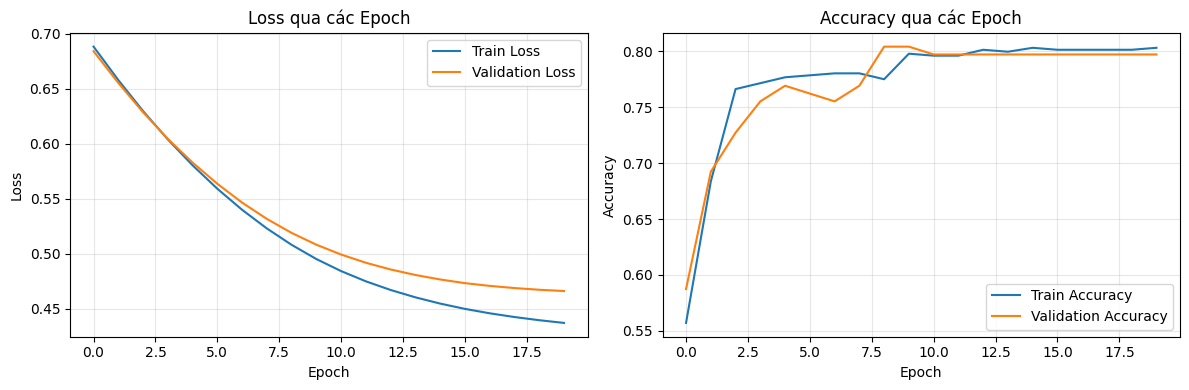

In [18]:
plt.figure(figsize=(12, 4))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss qua các Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy qua các Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()